# Convolutionair Neuraal Netwerk (CNN)
Een Convolutionair Neuraal Netwerk (CNN) is een type kunstmatig neuraal netwerk dat voornamelijk wordt gebruikt voor het verwerken van gestructureerde gegevens zoals afbeeldingen. CNN's maken gebruik van convolutionele lagen die filters toepassen op de invoerdata om kenmerken te extraheren, gevolgd door pooling-lagen die de ruimtelijke dimensies van de gegevens verminderen. Dit maakt CNN's bijzonder effectief voor taken zoals beeldclassificatie, objectdetectie en gezichtsherkenning.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold, StratifiedKFold

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from utils.whole_dataset_tf import create_libs_tensorflow_dataset_from_dataframe_normalized

In [2]:
df = pd.read_csv('../data/csv/processed_data.csv')

In [3]:
train_dataset, val_dataset, test_dataset, label_encoder, dataset_info = create_libs_tensorflow_dataset_from_dataframe_normalized(df, 
                                                                                                                                 batch_size=64, 
                                                                                                                                 normalize_data=False,
                                                                                                                                 dimensionality_reduction='pca',
                                                                                                                                 pca_components=18)

🎯 Using ORIGIN as target variable
📊 Processing DataFrame with 51,453 samples...
🔧 Dimensionality reduction: PCA
Found 8001 wavelength features
Wavelength range: 200.0 - 1000.0 nm
🔄 Extracting spectral data and labels...
🔄 Encoding labels...
Label encoding: {'innerliner': 0, 'sidewall': 1, 'tread': 2}

📊 Class distribution (origin):
  innerliner: 17,260 samples (33.5%)
  sidewall: 16,257 samples (31.6%)
  tread: 17,936 samples (34.9%)

🔄 Applying PCA dimensionality reduction...
  ✅ PCA: 8001 → 18 features
  📊 Variance explained: 0.951

🔄 Splitting data...
Train set: 32,929 samples
Validation set: 8,233 samples
Test set: 10,291 samples

🔄 Creating TensorFlow datasets...

🎯 TensorFlow Dataset created successfully!
   • Target variable: ORIGIN
   • Total samples: 51,453
   • Features per sample: 18 (reduced from 8,001)
   • Feature reduction: 99.8%
   • Classes: 3 (innerliner, sidewall, tread)
   • Original wavelength range: 200.0 - 1000.0 nm
   • Data normalized: False
   • Dimensionality

In [4]:
print(dataset_info)

{'total_samples': 51453, 'train_samples': 32929, 'val_samples': 8233, 'test_samples': 10291, 'n_features': 18, 'original_n_features': 8001, 'n_classes': 3, 'class_names': ['innerliner', 'sidewall', 'tread'], 'feature_shape': (18,), 'steps_per_epoch': 514, 'validation_steps': 128, 'wavelength_range': (200.0, 1000.0), 'target_column': 'origin', 'predicting_brands': False, 'normalized': False, 'data_type': 'float32', 'dimensionality_reduction': {'method': 'pca', 'n_components': 18, 'variance_explained': 0.9507191, 'explained_variance_ratio': array([0.29161632, 0.24048541, 0.11773053, 0.06721523, 0.05724566,
       0.04047697, 0.03222724, 0.02336817, 0.01827152, 0.01551166,
       0.01048158, 0.00897225, 0.00627839, 0.00560639, 0.00505371,
       0.00387736, 0.00322246, 0.0030782 ], dtype=float32), 'pca_model': PCA(n_components=18)}}


We maken gebruik van de Swish activatie functie in plaats van ReLU, omdat Swish vaak betere prestaties levert in diepe netwerken door zijn gladde aard en vermogen om negatieve waarden door te laten, wat kan helpen bij het leren van complexere patronen.


In [5]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau

input_shape = (train_dataset.element_spec[0].shape[1],)

model = keras.Sequential([
    layers.Reshape((input_shape[0], 1), input_shape=input_shape),

    layers.Conv1D(64, kernel_size=5, activation='swish', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.5),

    layers.Conv1D(128, kernel_size=5, activation='swish', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.5),

    layers.Conv1D(128, kernel_size=5, activation='swish', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.5),

    layers.Conv1D(256, kernel_size=5, activation='swish', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.5),

    layers.Conv1D(256, kernel_size=3, activation='swish', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),

    # Dense laag
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 18, 1)             0         
                                                                 
 conv1d (Conv1D)             (None, 18, 64)            384       
                                                                 
 batch_normalization (BatchN  (None, 18, 64)           256       
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  (None, 9, 64)            0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 9, 64)             0         
                                                                 
 conv1d_1 (Conv1D)           (None, 9, 128)            4

In [6]:
def get_callbacks(patience=5):
    """Standard callbacks for training"""
    return [
        # EarlyStopping(
        #     monitor='val_loss',
        #     patience=patience,
        #     restore_best_weights=True,
        #     verbose=1
        # ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=patience,
            min_lr=1e-7,
            verbose=1
        )
    ]

In [7]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=get_callbacks()
)
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test accuracy: {test_accuracy:.4f}')

Epoch 1/100
515/515 [==============================] - 14s 14ms/step - loss: 0.7932 - accuracy: 0.6706 - val_loss: 0.4126 - val_accuracy: 0.8351 - lr: 0.0010
Epoch 2/100
515/515 [==============================] - 8s 15ms/step - loss: 0.5019 - accuracy: 0.8001 - val_loss: 0.3280 - val_accuracy: 0.8658 - lr: 0.0010
Epoch 3/100
515/515 [==============================] - 7s 13ms/step - loss: 0.4361 - accuracy: 0.8302 - val_loss: 0.2795 - val_accuracy: 0.8842 - lr: 0.0010
Epoch 4/100
515/515 [==============================] - 8s 15ms/step - loss: 0.4005 - accuracy: 0.8455 - val_loss: 0.2611 - val_accuracy: 0.8952 - lr: 0.0010
Epoch 5/100
515/515 [==============================] - 7s 14ms/step - loss: 0.3743 - accuracy: 0.8528 - val_loss: 0.2421 - val_accuracy: 0.9042 - lr: 0.0010
Epoch 6/100
515/515 [==============================] - 7s 15ms/step - loss: 0.3604 - accuracy: 0.8596 - val_loss: 0.2361 - val_accuracy: 0.9068 - lr: 0.0010
Epoch 7/100
515/515 [==============================] - 7s

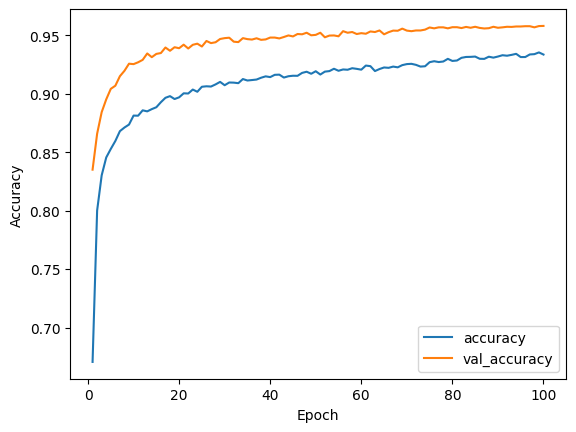

In [8]:
import matplotlib.pyplot as plt

acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
epochs=range(1, len(val_acc)+1)                        
plt.plot(epochs, acc, label='accuracy')
plt.plot(epochs, val_acc, label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [9]:
print(len(history.history['val_accuracy']))

100


129/129 [==============================] - 1s 3ms/step
Predictions shape: (8233, 3)
Sample predictions:
[[4.0648118e-02 9.5414293e-01 5.2090059e-03]
 [7.0523215e-04 9.9922180e-01 7.2938601e-05]
 [7.4850554e-06 2.2523392e-03 9.9774015e-01]]
Predicted classes shape: (8233,)
Sample predicted classes: [1 1 2 1 2 1 0 2 0 2]
True labels shape: (8233,)
Sample true labels: [1 1 2 1 2 1 0 2 0 2]
Confusion Matrix:
[[2683   29   50]
 [  38 2446  117]
 [  19   93 2758]]


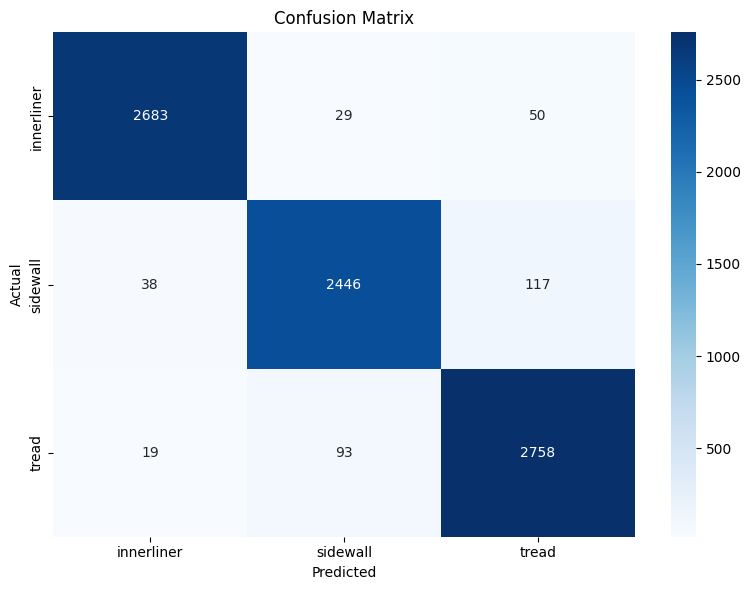


Classification Report:
              precision    recall  f1-score   support

  innerliner       0.98      0.97      0.98      2762
    sidewall       0.95      0.94      0.95      2601
       tread       0.94      0.96      0.95      2870

    accuracy                           0.96      8233
   macro avg       0.96      0.96      0.96      8233
weighted avg       0.96      0.96      0.96      8233



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from the model
predictions = model.predict(val_dataset)
print(f"Predictions shape: {predictions.shape}")  # Should be (n_samples, 3)
print(f"Sample predictions:\n{predictions[:3]}")  # Show first 3 predictions

# Convert probabilities to class predictions using argmax
y_pred = np.argmax(predictions, axis=1)  # Convert to class indices [0, 1, 2]
print(f"Predicted classes shape: {y_pred.shape}")  # Should be (n_samples,)
print(f"Sample predicted classes: {y_pred[:10]}")  # Should be integers like [0, 1, 2, 1, 0...]

# Get true labels
y_true = np.concatenate([y for x, y in val_dataset], axis=0)
print(f"True labels shape: {y_true.shape}")  # Should be (n_samples,)
print(f"Sample true labels: {y_true[:10]}")  # Should be integers like [0, 1, 2, 1, 0...]

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix with proper labels
plt.figure(figsize=(8, 6))
class_names = label_encoder.classes_  
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=class_names, 
           yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [11]:
def keras_model_memory_usage_in_bytes(model, *, batch_size: int):
    """
    Return the estimated memory usage of a given Keras model in bytes.
    This includes the model weights and layers, but excludes the dataset.
    The model shapes are multipled by the batch size, but the weights are not.
    Args:
        model: A Keras model.
        batch_size: The batch size you intend to run the model with. If you
            have already specified the batch size in the model itself, then
            pass `1` as the argument here.
    Returns:
        An estimate of the Keras model's memory usage in bytes.
    """
    default_dtype = tf.keras.backend.floatx()
    shapes_mem_count = 0
    internal_model_mem_count = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            internal_model_mem_count += keras_model_memory_usage_in_bytes(
                layer, batch_size=batch_size
            )
        single_layer_mem = tf.as_dtype(layer.dtype or default_dtype).size
        out_shape = layer.output_shape
        if isinstance(out_shape, list):
            out_shape = out_shape[0]
        for s in out_shape:
            if s is None:
                continue
            single_layer_mem *= s
        shapes_mem_count += single_layer_mem

    trainable_count = sum(
        [tf.keras.backend.count_params(p) for p in model.trainable_weights]
    )
    non_trainable_count = sum(
        [tf.keras.backend.count_params(p) for p in model.non_trainable_weights]
    )

    total_memory = (
        batch_size * shapes_mem_count
        + internal_model_mem_count
        + trainable_count
        + non_trainable_count
    )
    return total_memory

In [12]:
model_memory = keras_model_memory_usage_in_bytes(model, batch_size=64)
print(f"Estimated model memory usage: {model_memory / (1024 ** 2):.2f} MB")

Estimated model memory usage: 3.25 MB


In [13]:
# Simple solution for quick inference timing
import time

# Method 1: Time the entire validation dataset
print("Timing full validation dataset prediction...")
start_time = time.perf_counter()
predictions = model.predict(val_dataset, verbose=0)
end_time = time.perf_counter()

total_time_ms = (end_time - start_time) * 1000
num_samples = predictions.shape[0]
time_per_sample = total_time_ms / num_samples

print(f"Total inference time: {total_time_ms:.2f} ms")
print(f"Number of samples: {num_samples}")
print(f"Time per sample: {time_per_sample:.4f} ms")
print(f"Samples per second: {1000/time_per_sample:.0f}")

Timing full validation dataset prediction...
Total inference time: 418.76 ms
Number of samples: 8233
Time per sample: 0.0509 ms
Samples per second: 19660


🔬 CLASS PROTOTYPE GENERATION AND ANALYSIS
📊 Extracting validation data...
   Validation data shape: (8233, 18)
   Classes: ['innerliner' 'sidewall' 'tread']

🔬 Generating Statistical Class Prototypes...
   📊 innerliner: 2762 samples
   📊 sidewall: 2601 samples
   📊 tread: 2870 samples
📈 Visualizing statistical Class Prototypes...


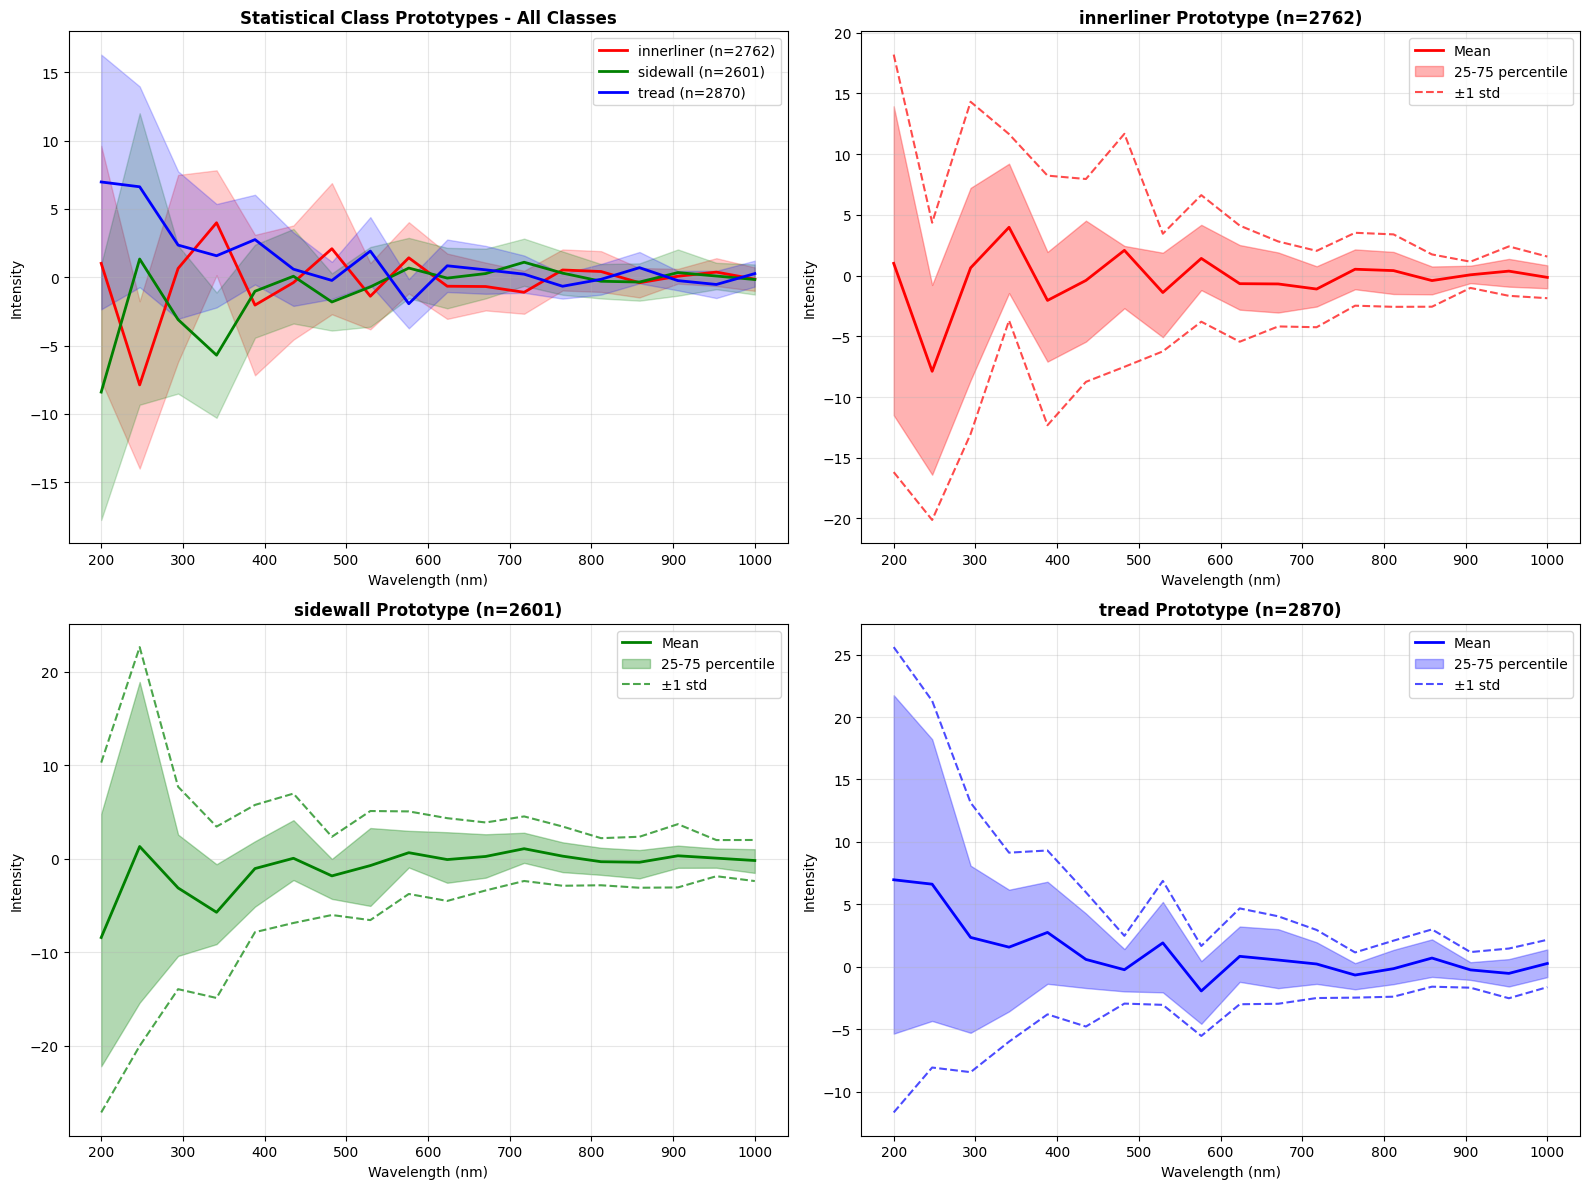

🔍 Analyzing Class Separability for statistical prototypes...

📊 Pairwise distances between class prototypes:
             innerliner   sidewall      tread
innerliner         0.00      17.48      17.76 
sidewall                      0.00      19.55 
tread                                    0.00 

🎯 Most separable classes: sidewall - tread (distance: 19.55)
🔍 Least separable classes: innerliner - sidewall (distance: 17.48)


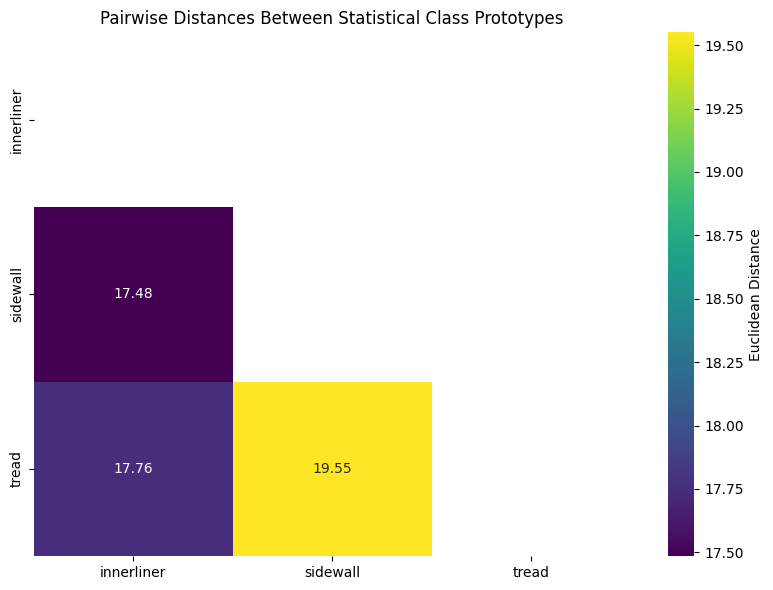


🎯 Generating Medoid Class Prototypes...
   🎯 innerliner: Medoid from sample #5081 (2762 samples)
   🎯 sidewall: Medoid from sample #3787 (2601 samples)
   🎯 tread: Medoid from sample #7341 (2870 samples)
📈 Visualizing medoid Class Prototypes...


C:\Users\joost\AppData\Local\Temp\ipykernel_10760\3398263910.py:325: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


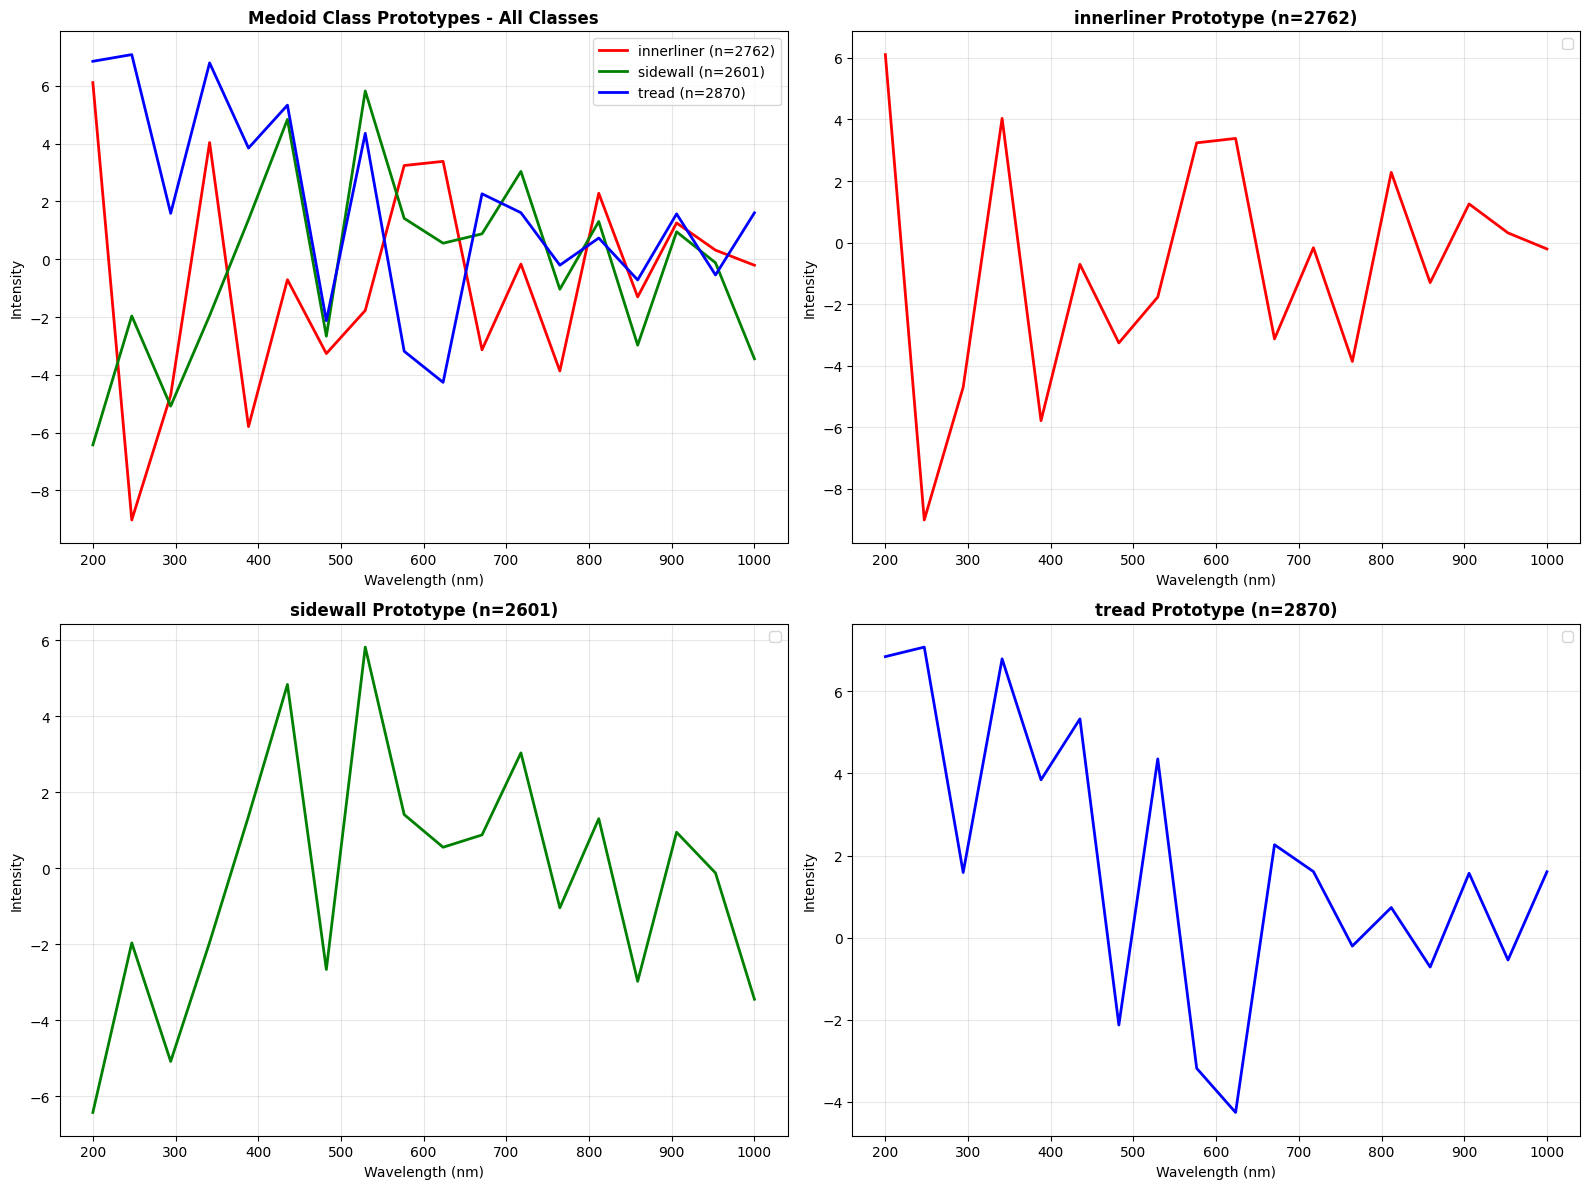

🔍 Analyzing Class Separability for medoid prototypes...

📊 Pairwise distances between class prototypes:
             innerliner   sidewall      tread
innerliner         0.00      21.05      25.04 
sidewall                      0.00      21.63 
tread                                    0.00 

🎯 Most separable classes: innerliner - tread (distance: 25.04)
🔍 Least separable classes: innerliner - sidewall (distance: 21.05)


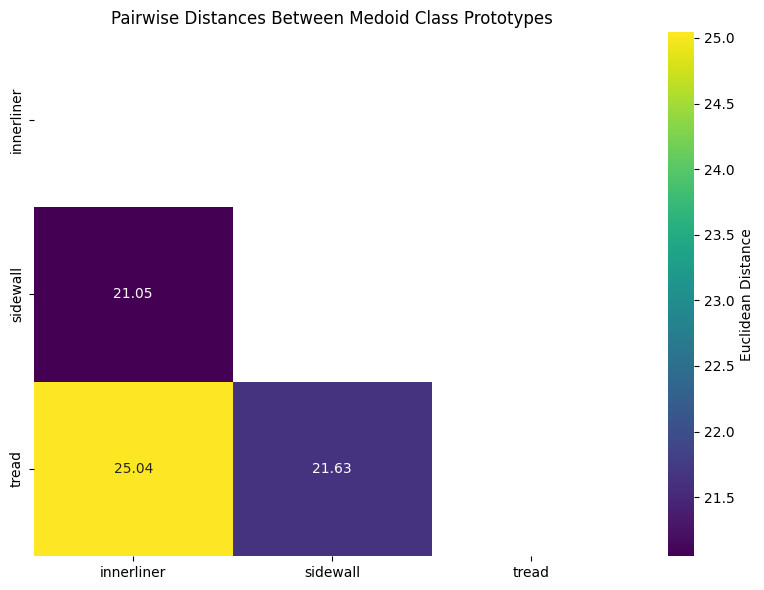


🧠 Generating Feature Space Class Prototypes...
   🧠 innerliner: Feature prototype from 2762 samples
   🧠 sidewall: Feature prototype from 2601 samples
   🧠 tread: Feature prototype from 2870 samples

🎯 Feature Space Analysis:
   innerliner: 256 features, distance to closest: 2.4243
   sidewall: 256 features, distance to closest: 1.2167
   tread: 256 features, distance to closest: 1.5741


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
import tensorflow as tf

def extract_features_from_layer(model, dataset, layer_name_or_index=-3):
    """
    Extract features from a specific layer of the model
    
    Parameters:
    -----------
    model : tf.keras.Model
        Trained model
    dataset : tf.data.Dataset
        Dataset to extract features from
    layer_name_or_index : str or int
        Layer name or index to extract features from (default: -3 for second-to-last dense layer)
    
    Returns:
    --------
    features : np.array
        Extracted features
    labels : np.array
        Corresponding labels
    """
    
    # Create feature extraction model
    if isinstance(layer_name_or_index, int):
        feature_extractor = tf.keras.Model(
            inputs=model.input,
            outputs=model.layers[layer_name_or_index].output
        )
    else:
        feature_extractor = tf.keras.Model(
            inputs=model.input,
            outputs=model.get_layer(layer_name_or_index).output
        )
    
    # Extract features and labels
    features_list = []
    labels_list = []
    
    for x_batch, y_batch in dataset:
        batch_features = feature_extractor.predict(x_batch, verbose=0)
        features_list.append(batch_features)
        labels_list.append(y_batch.numpy())
    
    features = np.concatenate(features_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    
    return features, labels

def generate_class_prototypes_statistical(X_data, y_data, label_encoder):
    """
    Generate class prototypes using statistical methods (mean, median)
    
    Parameters:
    -----------
    X_data : np.array
        Input spectra data
    y_data : np.array
        Labels
    label_encoder : sklearn.preprocessing.LabelEncoder
        Label encoder
    
    Returns:
    --------
    prototypes : dict
        Dictionary containing prototypes for each class
    """
    
    print("🔬 Generating Statistical Class Prototypes...")
    
    prototypes = {}
    class_names = label_encoder.classes_
    
    for class_idx, class_name in enumerate(class_names):
        # Get all samples for this class
        class_mask = (y_data == class_idx)
        class_samples = X_data[class_mask]
        
        if len(class_samples) == 0:
            print(f"⚠️  Warning: No samples found for class {class_name}")
            continue
        
        # Calculate different prototypes
        mean_prototype = np.mean(class_samples, axis=0)
        median_prototype = np.median(class_samples, axis=0)
        std_prototype = np.std(class_samples, axis=0)
        
        # Calculate confidence intervals
        percentile_25 = np.percentile(class_samples, 25, axis=0)
        percentile_75 = np.percentile(class_samples, 75, axis=0)
        
        prototypes[class_name] = {
            'mean': mean_prototype,
            'median': median_prototype,
            'std': std_prototype,
            'percentile_25': percentile_25,
            'percentile_75': percentile_75,
            'n_samples': len(class_samples),
            'class_idx': class_idx
        }
        
        print(f"   📊 {class_name}: {len(class_samples)} samples")
    
    return prototypes

def generate_class_prototypes_medoid(X_data, y_data, label_encoder):
    """
    Generate class prototypes using medoid (most representative sample)
    
    Parameters:
    -----------
    X_data : np.array
        Input spectra data  
    y_data : np.array
        Labels
    label_encoder : sklearn.preprocessing.LabelEncoder
        Label encoder
    
    Returns:
    --------
    prototypes : dict
        Dictionary containing medoid prototypes for each class
    """
    
    print("🎯 Generating Medoid Class Prototypes...")
    
    prototypes = {}
    class_names = label_encoder.classes_
    
    for class_idx, class_name in enumerate(class_names):
        # Get all samples for this class
        class_mask = (y_data == class_idx)
        class_samples = X_data[class_mask]
        class_indices = np.where(class_mask)[0]
        
        if len(class_samples) == 0:
            continue
        
        if len(class_samples) == 1:
            medoid_spectrum = class_samples[0]
            medoid_idx = class_indices[0]
        else:
            # Calculate pairwise distances within the class
            distances = pairwise_distances(class_samples, metric='euclidean')
            
            # Find the sample with minimum sum of distances (medoid)
            sum_distances = np.sum(distances, axis=1)
            medoid_local_idx = np.argmin(sum_distances)
            medoid_idx = class_indices[medoid_local_idx]
            medoid_spectrum = class_samples[medoid_local_idx]
        
        prototypes[class_name] = {
            'medoid_spectrum': medoid_spectrum,
            'medoid_index': medoid_idx,
            'n_samples': len(class_samples),
            'class_idx': class_idx
        }
        
        print(f"   🎯 {class_name}: Medoid from sample #{medoid_idx} ({len(class_samples)} samples)")
    
    return prototypes

def generate_class_prototypes_feature_space(model, dataset, label_encoder, layer_index=-3):
    """
    Generate class prototypes in the learned feature space
    
    Parameters:
    -----------
    model : tf.keras.Model
        Trained model
    dataset : tf.data.Dataset
        Dataset to analyze
    label_encoder : sklearn.preprocessing.LabelEncoder
        Label encoder
    layer_index : int
        Which layer to extract features from
    
    Returns:
    --------
    prototypes : dict
        Dictionary containing feature space prototypes
    """
    
    print("🧠 Generating Feature Space Class Prototypes...")
    
    # Extract features from the specified layer
    features, labels = extract_features_from_layer(model, dataset, layer_index)
    
    prototypes = {}
    class_names = label_encoder.classes_
    
    for class_idx, class_name in enumerate(class_names):
        # Get features for this class
        class_mask = (labels == class_idx)
        class_features = features[class_mask]
        
        if len(class_features) == 0:
            continue
        
        # Calculate prototype in feature space
        mean_features = np.mean(class_features, axis=0)
        std_features = np.std(class_features, axis=0)
        
        # Find the sample closest to the mean in feature space
        distances = np.linalg.norm(class_features - mean_features, axis=1)
        closest_idx = np.argmin(distances)
        
        prototypes[class_name] = {
            'mean_features': mean_features,
            'std_features': std_features,
            'closest_sample_features': class_features[closest_idx],
            'feature_space_distance': distances[closest_idx],
            'n_samples': len(class_features),
            'class_idx': class_idx
        }
        
        print(f"   🧠 {class_name}: Feature prototype from {len(class_features)} samples")
    
    return prototypes

def visualize_class_prototypes(prototypes, wavelength_columns=None, prototype_type='statistical'):
    """
    Visualize class prototypes
    
    Parameters:
    -----------
    prototypes : dict
        Generated prototypes
    wavelength_columns : list or None
        Wavelength values for x-axis
    prototype_type : str
        Type of prototype to visualize
    """
    
    print(f"📈 Visualizing {prototype_type} Class Prototypes...")
    
    n_classes = len(prototypes)
    
    if n_classes == 0:
        print("No prototypes to visualize!")
        return
    
    # Setup wavelength axis
    if wavelength_columns is not None:
        x_axis = [float(wl) for wl in wavelength_columns]
        x_label = 'Wavelength (nm)'
    else:
        # Use the first prototype to determine length
        first_prototype = list(prototypes.values())[0]
        if prototype_type == 'statistical':
            spectrum_length = len(first_prototype['mean'])
        elif prototype_type == 'medoid':
            spectrum_length = len(first_prototype['medoid_spectrum'])
        
        x_axis = range(spectrum_length)
        x_label = 'Feature Index'
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()
    
    # Colors for each class
    colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown'][:n_classes]
    
    # Plot 1: All prototypes together
    ax = axes[0]
    for i, (class_name, proto_data) in enumerate(prototypes.items()):
        if prototype_type == 'statistical':
            y_data = proto_data['mean']
            std_data = proto_data['std']
            
            # Plot mean spectrum
            ax.plot(x_axis, y_data, color=colors[i], label=f'{class_name} (n={proto_data["n_samples"]})', linewidth=2)
            
            # Add confidence bands
            ax.fill_between(x_axis, 
                           y_data - std_data/2, 
                           y_data + std_data/2, 
                           alpha=0.2, color=colors[i])
        
        elif prototype_type == 'medoid':
            y_data = proto_data['medoid_spectrum']
            ax.plot(x_axis, y_data, color=colors[i], label=f'{class_name} (n={proto_data["n_samples"]})', linewidth=2)
    
    ax.set_title(f'{prototype_type.title()} Class Prototypes - All Classes', fontweight='bold')
    ax.set_xlabel(x_label)
    ax.set_ylabel('Intensity')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Individual class prototypes with statistics
    for i, (class_name, proto_data) in enumerate(prototypes.items()):
        if i >= 3:  # Only show first 3 classes in individual plots
            break
            
        ax = axes[i + 1]
        
        if prototype_type == 'statistical':
            mean_data = proto_data['mean']
            std_data = proto_data['std']
            p25_data = proto_data['percentile_25']
            p75_data = proto_data['percentile_75']
            
            # Plot mean
            ax.plot(x_axis, mean_data, color=colors[i], label='Mean', linewidth=2)
            
            # Plot percentiles
            ax.fill_between(x_axis, p25_data, p75_data, alpha=0.3, color=colors[i], label='25-75 percentile')
            
            # Plot std bounds
            ax.plot(x_axis, mean_data + std_data, '--', color=colors[i], alpha=0.7, label='±1 std')
            ax.plot(x_axis, mean_data - std_data, '--', color=colors[i], alpha=0.7)
        
        elif prototype_type == 'medoid':
            medoid_data = proto_data['medoid_spectrum']
            ax.plot(x_axis, medoid_data, color=colors[i], linewidth=2)
        
        ax.set_title(f'{class_name} Prototype (n={proto_data["n_samples"]})', fontweight='bold')
        ax.set_xlabel(x_label)
        ax.set_ylabel('Intensity')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Remove unused subplot
    if n_classes <= 3:
        for j in range(n_classes + 1, 4):
            fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

def analyze_class_separability(prototypes, prototype_type='statistical'):
    """
    Analyze separability between class prototypes
    
    Parameters:
    -----------
    prototypes : dict
        Generated prototypes
    prototype_type : str
        Type of prototype to analyze
    """
    
    print(f"🔍 Analyzing Class Separability for {prototype_type} prototypes...")
    
    class_names = list(prototypes.keys())
    n_classes = len(class_names)
    
    # Extract prototype spectra
    prototype_spectra = []
    for class_name in class_names:
        if prototype_type == 'statistical':
            prototype_spectra.append(prototypes[class_name]['mean'])
        elif prototype_type == 'medoid':
            prototype_spectra.append(prototypes[class_name]['medoid_spectrum'])
    
    prototype_spectra = np.array(prototype_spectra)
    
    # Calculate pairwise distances
    distances = pairwise_distances(prototype_spectra, metric='euclidean')
    
    print(f"\n📊 Pairwise distances between class prototypes:")
    print(f"{'':12s} " + " ".join([f"{name:>10s}" for name in class_names]))
    
    for i, class_name_i in enumerate(class_names):
        row = f"{class_name_i:12s} "
        for j, class_name_j in enumerate(class_names):
            if i <= j:
                row += f"{distances[i,j]:10.2f} "
            else:
                row += f"{'':10s} "
        print(row)
    
    # Find most and least separable pairs
    upper_triangle = np.triu(distances, k=1)
    non_zero_distances = upper_triangle[upper_triangle > 0]
    
    if len(non_zero_distances) > 0:
        max_distance_idx = np.unravel_index(np.argmax(upper_triangle), upper_triangle.shape)
        min_distance_idx = np.unravel_index(
            np.argmax(np.where(upper_triangle > 0, upper_triangle, np.inf)), 
            upper_triangle.shape
        )
        
        # Actually find minimum non-zero distance
        masked_distances = np.where(upper_triangle > 0, upper_triangle, np.inf)
        min_distance_idx = np.unravel_index(np.argmin(masked_distances), masked_distances.shape)
        
        print(f"\n🎯 Most separable classes: {class_names[max_distance_idx[0]]} - {class_names[max_distance_idx[1]]} (distance: {distances[max_distance_idx]:.2f})")
        print(f"🔍 Least separable classes: {class_names[min_distance_idx[0]]} - {class_names[min_distance_idx[1]]} (distance: {distances[min_distance_idx]:.2f})")
    
    # Visualize distance matrix
    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(distances, dtype=bool))
    sns.heatmap(distances, mask=mask, annot=True, fmt='.2f', cmap='viridis',
                xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Euclidean Distance'})
    plt.title(f'Pairwise Distances Between {prototype_type.title()} Class Prototypes')
    plt.tight_layout()
    plt.show()

# Main implementation
def generate_and_analyze_class_prototypes(model, datasets, label_encoder, dataset_info):
    """
    Main function to generate and analyze class prototypes
    
    Parameters:
    -----------
    model : tf.keras.Model
        Trained model
    datasets : tuple
        (train_dataset, val_dataset, test_dataset)
    label_encoder : sklearn.preprocessing.LabelEncoder
        Label encoder
    dataset_info : dict
        Information about the dataset
    """
    
    print("=" * 80)
    print("🔬 CLASS PROTOTYPE GENERATION AND ANALYSIS")
    print("=" * 80)
    
    train_dataset, val_dataset = datasets
    
    # Get original data for prototype generation
    print("📊 Extracting validation data...")
    X_val_list = []
    y_val_list = []
    
    for x_batch, y_batch in val_dataset:
        X_val_list.append(x_batch.numpy())
        y_val_list.append(y_batch.numpy())
    
    X_val = np.concatenate(X_val_list, axis=0)
    y_val = np.concatenate(y_val_list, axis=0)
    
    print(f"   Validation data shape: {X_val.shape}")
    print(f"   Classes: {label_encoder.classes_}")
    
    # Generate wavelength axis if available
    wavelength_columns = None
    if 'selected_wavelengths' in dataset_info:
        wavelength_columns = dataset_info['selected_wavelengths']
    elif 'wavelength_range' in dataset_info:
        # Generate wavelength range
        start, end = dataset_info['wavelength_range']
        wavelength_columns = np.linspace(start, end, X_val.shape[1])
    
    # 1. Statistical Prototypes
    print("\n" + "="*60)
    statistical_prototypes = generate_class_prototypes_statistical(X_val, y_val, label_encoder)
    visualize_class_prototypes(statistical_prototypes, wavelength_columns, 'statistical')
    analyze_class_separability(statistical_prototypes, 'statistical')
    
    # 2. Medoid Prototypes
    print("\n" + "="*60)
    medoid_prototypes = generate_class_prototypes_medoid(X_val, y_val, label_encoder)
    visualize_class_prototypes(medoid_prototypes, wavelength_columns, 'medoid')
    analyze_class_separability(medoid_prototypes, 'medoid')
    
    # 3. Feature Space Prototypes
    print("\n" + "="*60)
    feature_prototypes = generate_class_prototypes_feature_space(model, val_dataset, label_encoder)
    
    print("\n🎯 Feature Space Analysis:")
    for class_name, proto_data in feature_prototypes.items():
        print(f"   {class_name}: {len(proto_data['mean_features'])} features, distance to closest: {proto_data['feature_space_distance']:.4f}")
    
    return {
        'statistical': statistical_prototypes,
        'medoid': medoid_prototypes,
        'feature_space': feature_prototypes,
        'wavelength_columns': wavelength_columns
    }

# Run the analysis
prototype_results = generate_and_analyze_class_prototypes(
    model, 
    (train_dataset, val_dataset), 
    label_encoder, 
    dataset_info
)

In [16]:
# Predict the origin of tire 1, measurement_id 48

# Step 1: Find the specific sample in the dataframe
sample = df[(df['tire_number'] == 1) & (df['measurement_id'] == 48)]

if len(sample) == 0:
    print("❌ Sample not found! Tire 1, measurement_id 48 does not exist.")
else:
    print(f"✓ Found sample: Tire {sample['tire_number'].values[0]}, "
          f"Measurement ID {sample['measurement_id'].values[0]}, "
          f"True origin: {sample['origin'].values[0]}")
    
    # Step 2: Extract wavelength features (same as during training)
    non_feature_cols = ['tire_number', 'origin', 'measurement_id']
    wavelength_cols = [col for col in df.columns if col not in non_feature_cols]
    
    # Get the spectrum
    spectrum = sample[wavelength_cols].values
    print(f"   Spectrum shape: {spectrum.shape}")
    
    # Step 3: Apply the same PCA transformation used during training
    # The PCA transformer is stored in dataset_info
    if 'dimensionality_reduction' in dataset_info and 'pca_model' in dataset_info['dimensionality_reduction']:
        pca = dataset_info['dimensionality_reduction']['pca_model']
        spectrum_pca = pca.transform(spectrum)
        print(f"   After PCA: {spectrum_pca.shape}")
    else:
        print("⚠️  Warning: No PCA transformer found in dataset_info")
        spectrum_pca = spectrum
    
    # Step 4: Make prediction
    prediction_probs = model.predict(spectrum_pca, verbose=0)
    predicted_class_idx = np.argmax(prediction_probs, axis=1)[0]
    predicted_class_name = label_encoder.classes_[predicted_class_idx]
    
    # Step 5: Display results
    print("\n" + "="*60)
    print("🎯 PREDICTION RESULTS")
    print("="*60)
    print(f"Sample: Tire {sample['tire_number'].values[0]}, Measurement ID {sample['measurement_id'].values[0]}")
    print(f"True origin: {sample['origin'].values[0]}")
    print(f"Predicted origin: {predicted_class_name}")
    
    # Show confidence for each class
    print(f"\nClass Probabilities:")
    for i, class_name in enumerate(label_encoder.classes_):
        prob = prediction_probs[0, i] * 100
        bar = "█" * int(prob / 2)  # Visual bar (50 chars = 100%)
        marker = "✓" if class_name == sample['origin'].values[0] else " "
        print(f"  {marker} {class_name:12s}: {prob:5.2f}% {bar}")
    
    # Verdict
    if predicted_class_name == sample['origin'].values[0]:
        print(f"\n✅ CORRECT! Model predicted the right origin.")
    else:
        print(f"\n❌ INCORRECT! Model predicted '{predicted_class_name}' but true origin is '{sample['origin'].values[0]}'")
    
    print("="*60)

✓ Found sample: Tire 1, Measurement ID 48, True origin: tread
   Spectrum shape: (3, 8001)
   After PCA: (3, 18)

🎯 PREDICTION RESULTS
Sample: Tire 1, Measurement ID 48
True origin: tread
Predicted origin: tread

Class Probabilities:
    innerliner  :  0.20% 
    sidewall    :  1.35% 
  ✓ tread       : 98.45% █████████████████████████████████████████████████

✅ CORRECT! Model predicted the right origin.
